# CSE438 Lab 11: Image Segmentation — Thresholding and Region Growing

**Course:** CSE438 Digital Image Processing  
**Dataset:** Betel Leaf Image Dataset from Bangladesh  
**Platform:** Kaggle Notebook  
**Linked topics:** thresholding, adaptive/local thresholding, Otsu's method, region growing, segmentation evaluation  
**CO mapping:** CO3, CO4  

## Learning Objectives

After completing this lab, students should be able to:

1. apply global and adaptive thresholding for image segmentation;
2. implement Otsu's automatic threshold selection method using OpenCV;
3. implement a simple region growing algorithm from scratch;
4. compare segmentation masks visually;
5. evaluate segmentation masks using Intersection over Union (IoU).

## Lab Tasks

1. Apply manual global threshold.
2. Apply Otsu's automatic threshold.
3. Apply adaptive/local thresholding.
4. Implement simple region growing.
5. Evaluate with ground truth using IoU.

> **Important note about ground truth:**  
> The provided Betel Leaf dataset is primarily organized for image classification. It contains class folders but may not include pixel-wise segmentation masks. Therefore, this notebook supports two modes:
>
> - **Mode A:** use real ground-truth masks if a mask folder is added later;
> - **Mode B:** use a pseudo-reference foreground mask generated by GrabCut only for classroom demonstration of IoU calculation.
>
> Mode B should not be reported as a real supervised segmentation benchmark.

In [1]:
# ============================================================
# 1. Environment Setup
# ============================================================

import os
import glob
import math
import random
from collections import deque
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from skimage.measure import label
    SKIMAGE_AVAILABLE = True
except Exception:
    SKIMAGE_AVAILABLE = False

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = False

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("scikit-image available:", SKIMAGE_AVAILABLE)

OpenCV version: 4.13.0
NumPy version: 2.4.6
scikit-image available: True


## 2. Dataset Configuration

The dataset should be added to the Kaggle notebook through **Add Input**.  
The expected folders are:

```text
train/
  Bacterial Leaf Disease/
  Dried Leaf/
  Fungal Brown Spot Disease/
  Healthy Leaf/

test/
  Bacterial Leaf Disease/
  Dried Leaf/
  Fungal Brown Spot Disease/
  Healthy Leaf/
```

In [2]:
# ============================================================
# 2. Dataset Path Detection
# ============================================================

CLASS_NAMES = [
    "Bacterial Leaf Disease",
    "Dried Leaf",
    "Fungal Brown Spot Disease",
    "Healthy Leaf",
]

# User-provided and common Kaggle mount locations.
CANDIDATE_DATASET_DIRS = [
    Path("/kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh/data"),
    Path("/kaggle/input"),
]

def has_expected_structure(base_dir: Path) -> bool:
    """Return True if base_dir contains train/test folders with at least one expected class."""
    train_dir = base_dir / "train"
    test_dir = base_dir / "test"
    if not train_dir.exists() or not test_dir.exists():
        return False
    return any((train_dir / cls).exists() for cls in CLASS_NAMES)

def find_dataset_root() -> Path:
    """Find the dataset root robustly across common Kaggle input layouts."""
    for candidate in CANDIDATE_DATASET_DIRS:
        if has_expected_structure(candidate):
            return candidate

    # Recursive fallback search under /kaggle/input
    input_root = Path("/kaggle/input")
    if input_root.exists():
        for p in input_root.rglob("*"):
            if p.is_dir() and has_expected_structure(p):
                return p

    raise FileNotFoundError(
        "Could not find the Betel Leaf dataset root. "
        "Please add the Kaggle dataset as notebook input and verify the train/test folders."
    )

DATASET_ROOT = find_dataset_root()
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

OUTPUT_DIR = Path("/kaggle/working/cse438_lab11_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset root:", DATASET_ROOT)
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)
print("Output directory:", OUTPUT_DIR)

Dataset root: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh
Train directory: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train
Test directory: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/test
Output directory: /kaggle/working/cse438_lab11_outputs


In [3]:
# ============================================================
# 3. Dataset Utility Functions
# ============================================================

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

def list_images(split_dir: Path, class_name: str):
    """Return sorted image paths for one class folder."""
    class_dir = split_dir / class_name
    if not class_dir.exists():
        return []
    paths = []
    for ext in VALID_EXTENSIONS:
        paths.extend(class_dir.glob(f"*{ext}"))
        paths.extend(class_dir.glob(f"*{ext.upper()}"))
    return sorted(paths)

def build_count_table():
    """Create a class-wise train/test image-count table."""
    records = []
    for cls in CLASS_NAMES:
        train_count = len(list_images(TRAIN_DIR, cls))
        test_count = len(list_images(TEST_DIR, cls))
        records.append({
            "Class": cls,
            "Train Images": train_count,
            "Test Images": test_count,
            "Total": train_count + test_count
        })
    return pd.DataFrame(records)

count_df = build_count_table()
display(count_df)

if count_df["Total"].sum() == 0:
    raise RuntimeError("No images found. Check whether the dataset was mounted correctly.")

,Class,Train Images,Test Images,Total
0,Bacterial Leaf Disease,609,47,656
1,Dried Leaf,597,51,648
2,Fungal Brown Spot Disease,588,54,642
3,Healthy Leaf,594,49,643


In [4]:
# ============================================================
# 4. Image Loading and Visualization Helpers
# ============================================================

def read_image_rgb(path: Path, target_size=(384, 384)):
    """Read an image with OpenCV, convert BGR to RGB, and resize for stable lab execution."""
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Could not read image: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if target_size is not None:
        rgb = cv2.resize(rgb, target_size, interpolation=cv2.INTER_AREA)
    return rgb

def to_gray(rgb):
    """Convert RGB image to grayscale."""
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

def show_images(images, titles, cmap=None, cols=3, figsize=(14, 8)):
    """Display a list of images in a grid."""
    rows = int(math.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap or "gray")
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def save_gray(path: Path, image):
    """Save a grayscale image safely as uint8."""
    cv2.imwrite(str(path), np.clip(image, 0, 255).astype(np.uint8))

def save_rgb(path: Path, image):
    """Save an RGB image using OpenCV's BGR convention."""
    bgr = cv2.cvtColor(np.clip(image, 0, 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path), bgr)

Selected class: Healthy Leaf
Selected image: Healthy_Leaf-1-_jpg.rf.2bbab1284996789ca5375cbca7337959.jpg
RGB shape: (384, 384, 3)
Grayscale shape: (384, 384) | dtype: uint8


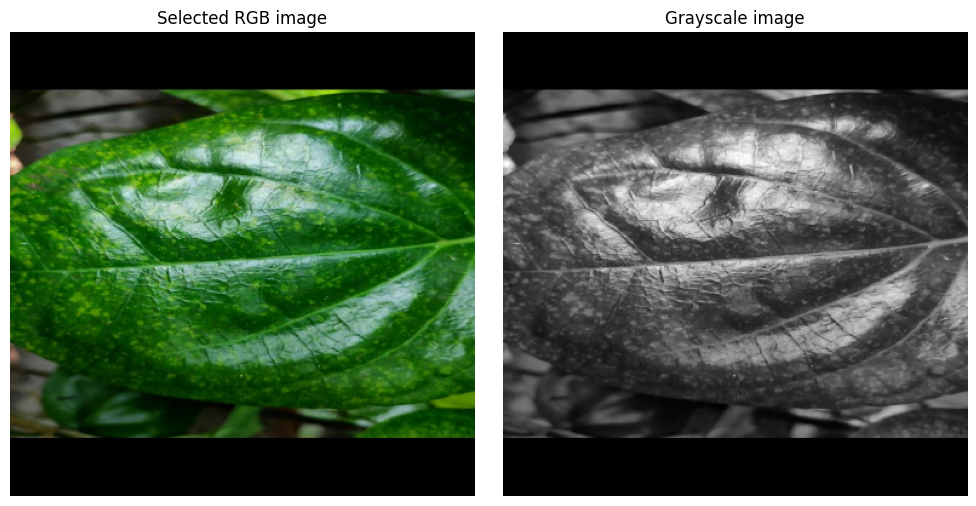

In [5]:
# ============================================================
# 5. Select a Representative Image
# ============================================================

# Prefer Healthy Leaf for foreground-background segmentation demonstration.
preferred_class = "Healthy Leaf"
candidate_paths = list_images(TRAIN_DIR, preferred_class)

# Fallback: use the first class that has images.
if len(candidate_paths) == 0:
    for cls in CLASS_NAMES:
        candidate_paths = list_images(TRAIN_DIR, cls)
        if len(candidate_paths) > 0:
            preferred_class = cls
            break

image_path = candidate_paths[0]
rgb = read_image_rgb(image_path, target_size=(384, 384))
gray = to_gray(rgb)

print("Selected class:", preferred_class)
print("Selected image:", image_path.name)
print("RGB shape:", rgb.shape)
print("Grayscale shape:", gray.shape, "| dtype:", gray.dtype)

show_images(
    [rgb, gray],
    ["Selected RGB image", "Grayscale image"],
    cols=2,
    figsize=(10, 5)
)

## 3. Manual Global Thresholding

Manual thresholding assigns each pixel to foreground or background using a fixed threshold value \(T\).  
For a grayscale image \(f(x,y)\), the binary output is:

\[
g(x,y)=
\begin{cases}
1, & f(x,y) \geq T \\
0, & f(x,y) < T
\end{cases}
\]

In practice, the correct threshold depends on illumination, contrast, background color, and object appearance.

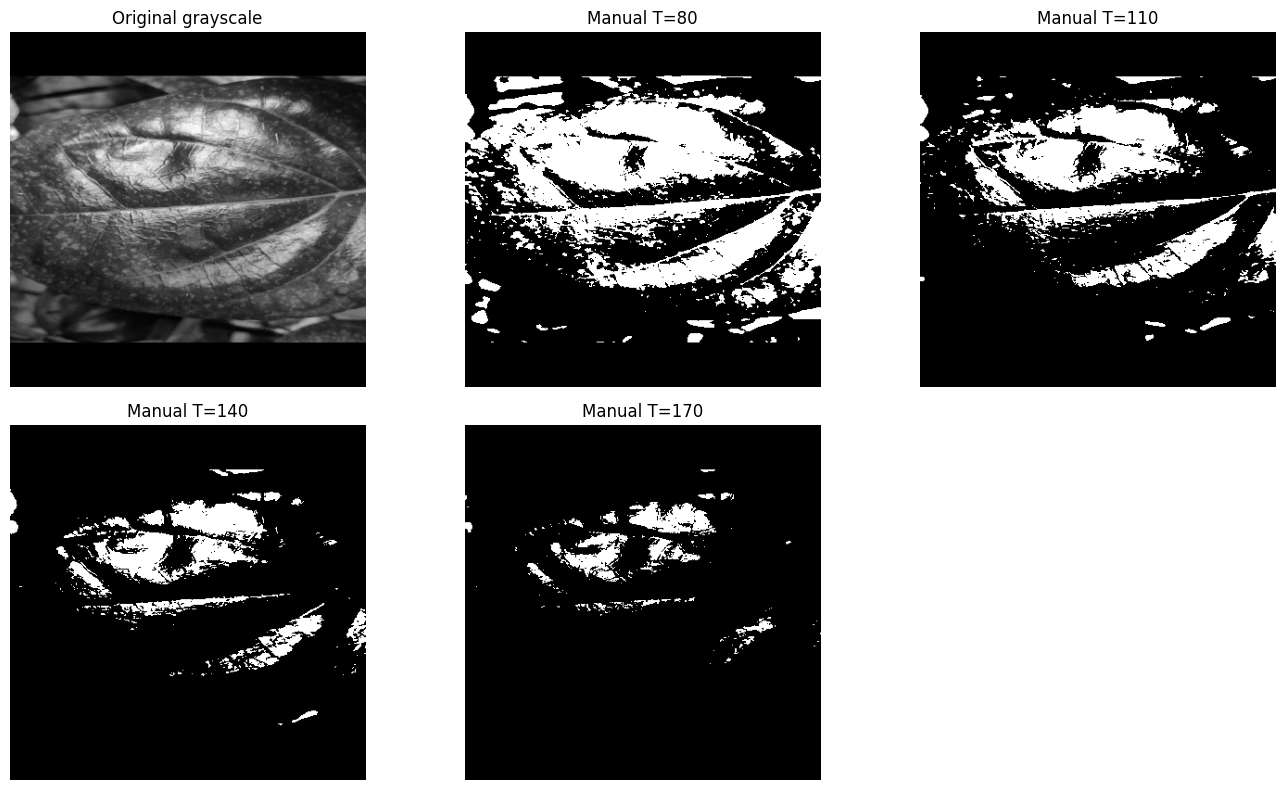

In [6]:
# ============================================================
# 6. Task 1: Manual Global Thresholding
# ============================================================

manual_thresholds = [80, 110, 140, 170]
manual_masks = {}

for T in manual_thresholds:
    _, mask = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)
    manual_masks[f"Manual T={T}"] = mask

show_images(
    [gray] + list(manual_masks.values()),
    ["Original grayscale"] + list(manual_masks.keys()),
    cmap="gray",
    cols=3,
    figsize=(14, 8)
)

# Save one representative output
save_gray(OUTPUT_DIR / "manual_threshold_T140.png", manual_masks["Manual T=140"])

## 4. Otsu's Automatic Thresholding

Otsu's method automatically estimates a threshold by minimizing within-class variance, or equivalently by maximizing between-class separability.  
It works best when foreground and background form two reasonably separable intensity groups.

Otsu threshold value: 73.0


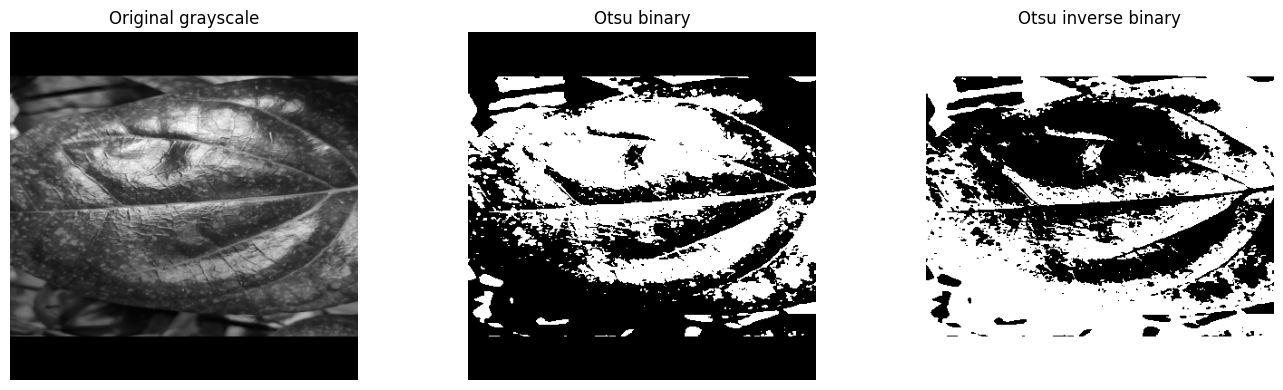

In [7]:
# ============================================================
# 7. Task 2: Otsu's Automatic Thresholding
# ============================================================

otsu_value, otsu_mask = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

otsu_inv_value, otsu_mask_inv = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Otsu threshold value:", otsu_value)

show_images(
    [gray, otsu_mask, otsu_mask_inv],
    ["Original grayscale", "Otsu binary", "Otsu inverse binary"],
    cmap="gray",
    cols=3,
    figsize=(14, 4)
)

save_gray(OUTPUT_DIR / "otsu_binary.png", otsu_mask)
save_gray(OUTPUT_DIR / "otsu_binary_inverse.png", otsu_mask_inv)

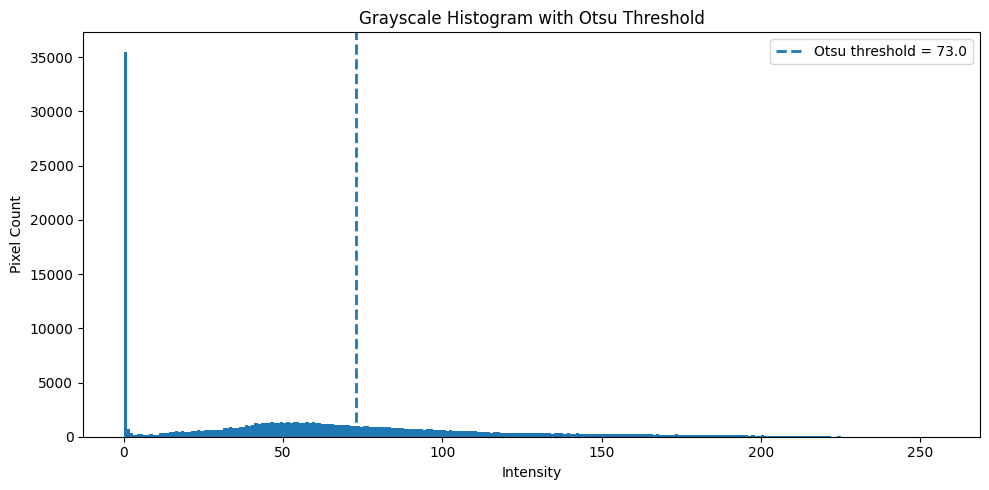

In [8]:
# ============================================================
# 8. Histogram with Otsu Threshold Marker
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(gray.ravel(), bins=256, range=(0, 256))
plt.axvline(otsu_value, linestyle="--", linewidth=2, label=f"Otsu threshold = {otsu_value:.1f}")
plt.title("Grayscale Histogram with Otsu Threshold")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Adaptive Thresholding

Adaptive thresholding calculates a local threshold for each neighborhood.  
This is useful when illumination changes across the image.

Two common variants are:

- **Adaptive Mean:** threshold is based on the local mean;
- **Adaptive Gaussian:** threshold is based on a weighted local mean.

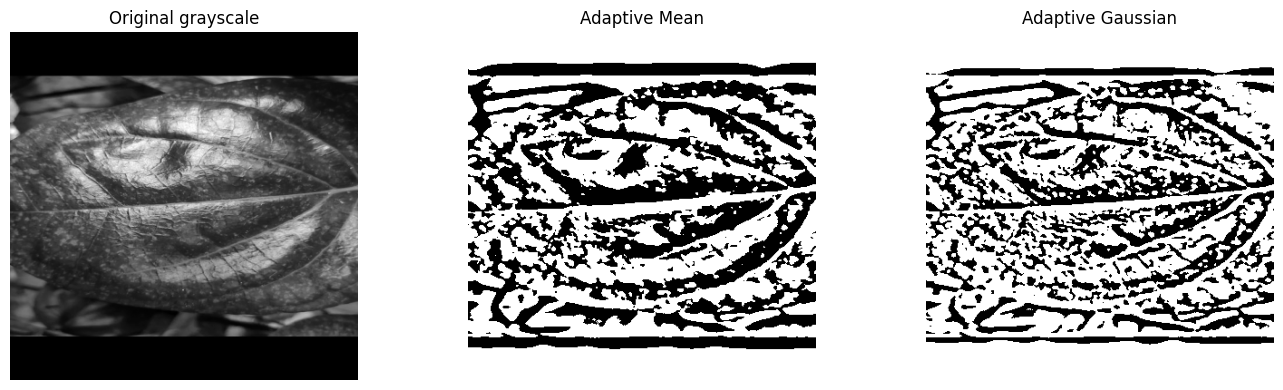

In [9]:
# ============================================================
# 9. Task 3: Adaptive Local Thresholding
# ============================================================

# Mild blur reduces isolated threshold noise.
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

adaptive_mean = cv2.adaptiveThreshold(
    gray_blur,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    blockSize=31,
    C=5
)

adaptive_gaussian = cv2.adaptiveThreshold(
    gray_blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=31,
    C=5
)

show_images(
    [gray, adaptive_mean, adaptive_gaussian],
    ["Original grayscale", "Adaptive Mean", "Adaptive Gaussian"],
    cmap="gray",
    cols=3,
    figsize=(14, 4)
)

save_gray(OUTPUT_DIR / "adaptive_mean.png", adaptive_mean)
save_gray(OUTPUT_DIR / "adaptive_gaussian.png", adaptive_gaussian)

## 6. Region Growing Segmentation

Region growing starts from one or more seed pixels and expands the region by adding neighboring pixels that satisfy a similarity criterion.  
Here, a pixel is accepted if its intensity is close to the current region mean within a selected tolerance.

In [10]:
# ============================================================
# 10. Region Growing Helper Functions
# ============================================================

def largest_connected_component(binary_mask):
    """
    Return the largest connected component from a binary foreground mask.
    This function is used only to estimate a reasonable seed point.
    """
    binary = (binary_mask > 0).astype(np.uint8)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return binary

    # Ignore label 0 because it is the background.
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.uint8)

def estimate_seed_from_mask(binary_mask):
    """Estimate a seed point from the centroid of the largest foreground component."""
    component = largest_connected_component(binary_mask)
    ys, xs = np.where(component > 0)

    if len(xs) == 0:
        h, w = binary_mask.shape
        return (w // 2, h // 2)

    return (int(np.mean(xs)), int(np.mean(ys)))

def region_growing_gray(image_gray, seed_xy, tolerance=18, connectivity=8):
    """
    Simple region growing on a grayscale image.

    Parameters
    ----------
    image_gray : np.ndarray
        Grayscale input image.
    seed_xy : tuple
        Seed point as (x, y).
    tolerance : int or float
        Maximum allowed absolute difference from current region mean.
    connectivity : int
        4 or 8 neighborhood connectivity.

    Returns
    -------
    np.ndarray
        Binary mask with foreground value 255.
    """
    h, w = image_gray.shape
    seed_x, seed_y = seed_xy

    if not (0 <= seed_x < w and 0 <= seed_y < h):
        raise ValueError("Seed point is outside image boundaries.")

    if connectivity == 4:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1),
                     (-1, -1), (-1, 1), (1, -1), (1, 1)]

    visited = np.zeros((h, w), dtype=bool)
    region = np.zeros((h, w), dtype=np.uint8)

    q = deque()
    q.append((seed_x, seed_y))
    visited[seed_y, seed_x] = True

    region_sum = float(image_gray[seed_y, seed_x])
    region_count = 1

    while q:
        x, y = q.popleft()
        current_mean = region_sum / region_count

        if abs(float(image_gray[y, x]) - current_mean) <= tolerance:
            region[y, x] = 255
            region_sum += float(image_gray[y, x])
            region_count += 1

            for dx, dy in neighbors:
                nx, ny = x + dx, y + dy
                if 0 <= nx < w and 0 <= ny < h and not visited[ny, nx]:
                    visited[ny, nx] = True
                    q.append((nx, ny))

    return region

# Estimate seed from the cleaner of Otsu/Otsu inverse by selecting the component
# whose area is neither extremely tiny nor almost the whole image.
candidate_foreground = largest_connected_component(otsu_mask_inv)
seed_xy = estimate_seed_from_mask(candidate_foreground)

print("Estimated seed point (x, y):", seed_xy)

Estimated seed point (x, y): (172, 296)


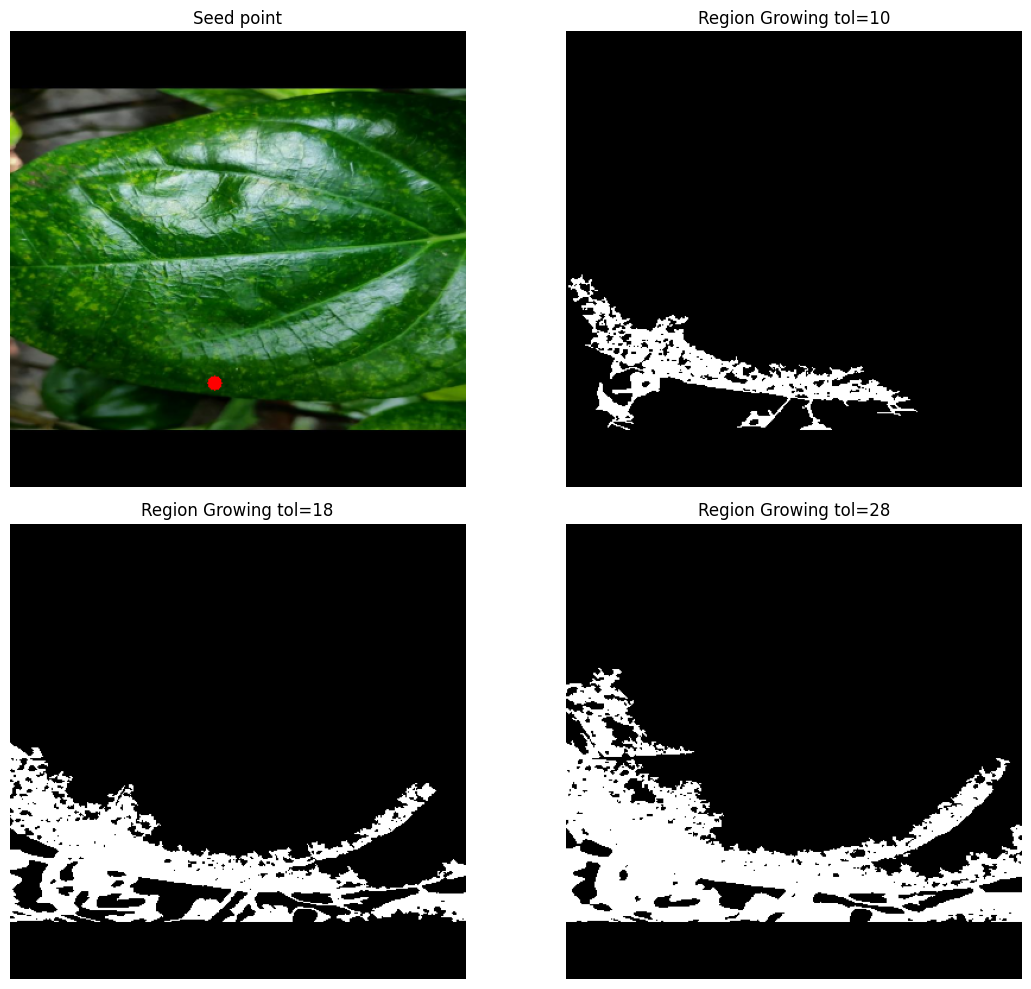

In [11]:
# ============================================================
# 11. Task 4: Simple Region Growing
# ============================================================

tolerances = [10, 18, 28]
region_masks = {}

for tol in tolerances:
    mask = region_growing_gray(gray, seed_xy=seed_xy, tolerance=tol, connectivity=8)
    region_masks[f"Region Growing tol={tol}"] = mask

# Draw seed point on the RGB image.
seed_display = rgb.copy()
cv2.circle(seed_display, seed_xy, radius=6, color=(255, 0, 0), thickness=-1)

show_images(
    [seed_display] + list(region_masks.values()),
    ["Seed point"] + list(region_masks.keys()),
    cmap="gray",
    cols=2,
    figsize=(12, 10)
)

save_rgb(OUTPUT_DIR / "region_growing_seed.png", seed_display)
for name, mask in region_masks.items():
    safe_name = name.lower().replace(" ", "_").replace("=", "")
    save_gray(OUTPUT_DIR / f"{safe_name}.png", mask)

## 7. Ground Truth or Pseudo-Reference Mask for IoU

For a true segmentation evaluation, a manually annotated ground-truth mask is required.  
If such masks are available later, set `GROUND_TRUTH_MASK_DIR` to the folder containing corresponding masks.

If no mask is available, the notebook creates a pseudo-reference foreground mask using GrabCut.  
This is useful for learning the IoU formula, but it is not a substitute for real annotation.

Pseudo-reference mask generated by GrabCut


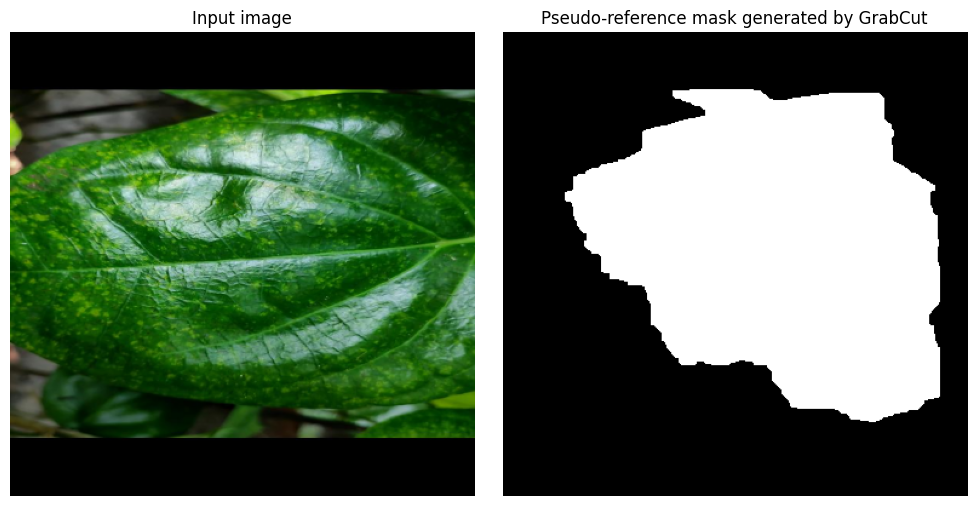

In [12]:
# ============================================================
# 12. Optional Ground Truth Mask Loading
# ============================================================

# If real segmentation masks are available, set this path manually.
# Example:
# GROUND_TRUTH_MASK_DIR = Path("/kaggle/input/betel-leaf-segmentation-masks")
GROUND_TRUTH_MASK_DIR = None

def find_matching_ground_truth_mask(image_path: Path, mask_dir):
    """
    Try to find a ground-truth mask with the same filename stem.
    This is optional and depends on whether mask annotations are provided.
    """
    if mask_dir is None:
        return None

    mask_dir = Path(mask_dir)
    if not mask_dir.exists():
        return None

    stem = image_path.stem
    for ext in VALID_EXTENSIONS:
        matches = list(mask_dir.rglob(f"{stem}{ext}")) + list(mask_dir.rglob(f"{stem}{ext.upper()}"))
        if matches:
            return matches[0]

    return None

def load_binary_mask(mask_path: Path, target_size=(384, 384)):
    """Load a ground-truth mask and convert it to a binary mask."""
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")

    if target_size is not None:
        mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return binary

def pseudo_reference_mask_grabcut(rgb_image):
    """
    Generate a pseudo-reference foreground mask with GrabCut.
    This is only for metric demonstration when no manual ground truth exists.
    """
    h, w = rgb_image.shape[:2]
    bgr = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2BGR)

    # Rectangle excludes a small border and assumes the main leaf is near the image center.
    margin_x = max(5, int(0.06 * w))
    margin_y = max(5, int(0.06 * h))
    rect = (margin_x, margin_y, w - 2 * margin_x, h - 2 * margin_y)

    mask = np.zeros((h, w), np.uint8)
    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)

    try:
        cv2.grabCut(bgr, mask, rect, bg_model, fg_model, 5, cv2.GC_INIT_WITH_RECT)
        foreground = np.where(
            (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
            255,
            0
        ).astype(np.uint8)
    except Exception:
        # Fallback to the largest component of inverse Otsu.
        foreground = largest_connected_component(otsu_mask_inv) * 255

    # Clean small holes/noise.
    kernel = np.ones((5, 5), np.uint8)
    foreground = cv2.morphologyEx(foreground, cv2.MORPH_OPEN, kernel)
    foreground = cv2.morphologyEx(foreground, cv2.MORPH_CLOSE, kernel)
    foreground = largest_connected_component(foreground) * 255

    return foreground.astype(np.uint8)

gt_path = find_matching_ground_truth_mask(image_path, GROUND_TRUTH_MASK_DIR)

if gt_path is not None:
    reference_mask = load_binary_mask(gt_path, target_size=(384, 384))
    reference_source = f"Manual ground truth mask: {gt_path.name}"
else:
    reference_mask = pseudo_reference_mask_grabcut(rgb)
    reference_source = "Pseudo-reference mask generated by GrabCut"

print(reference_source)

show_images(
    [rgb, reference_mask],
    ["Input image", reference_source],
    cmap="gray",
    cols=2,
    figsize=(10, 5)
)

save_gray(OUTPUT_DIR / "reference_mask_for_iou.png", reference_mask)

## 8. IoU Evaluation

Intersection over Union (IoU), also called the Jaccard index, measures overlap between a predicted segmentation mask and a reference mask.

\[
IoU = \frac{|A \cap B|}{|A \cup B|}
\]

where \(A\) is the predicted foreground region and \(B\) is the reference foreground region.

In [13]:
# ============================================================
# 13. Task 5: Evaluate Segmentation Masks with IoU
# ============================================================

def binarize_mask(mask):
    """Convert any mask to Boolean foreground."""
    return mask > 0

def iou_score(pred_mask, ref_mask):
    """Compute Intersection over Union."""
    pred = binarize_mask(pred_mask)
    ref = binarize_mask(ref_mask)

    intersection = np.logical_and(pred, ref).sum()
    union = np.logical_or(pred, ref).sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

def best_orientation_iou(mask, ref_mask):
    """
    Thresholding methods may produce foreground as either white or black.
    This function reports the better IoU between mask and its inverse.
    """
    direct_iou = iou_score(mask, ref_mask)
    inverse_iou = iou_score(255 - mask, ref_mask)

    if inverse_iou > direct_iou:
        return inverse_iou, "inverted"
    return direct_iou, "direct"

def foreground_ratio(mask):
    """Compute percentage of pixels marked as foreground."""
    return 100.0 * np.mean(mask > 0)

candidate_masks = {}

# Manual thresholds
candidate_masks.update(manual_masks)

# Otsu and adaptive
candidate_masks["Otsu"] = otsu_mask
candidate_masks["Otsu inverse"] = otsu_mask_inv
candidate_masks["Adaptive Mean"] = adaptive_mean
candidate_masks["Adaptive Gaussian"] = adaptive_gaussian

# Region growing
candidate_masks.update(region_masks)

records = []
for name, mask in candidate_masks.items():
    best_iou, orientation = best_orientation_iou(mask, reference_mask)
    records.append({
        "Method": name,
        "Best IoU": round(best_iou, 4),
        "Foreground Orientation": orientation,
        "Foreground Pixel (%)": round(foreground_ratio(mask), 2)
    })

iou_df = pd.DataFrame(records).sort_values(by="Best IoU", ascending=False).reset_index(drop=True)
display(iou_df)

best_method = iou_df.loc[0, "Method"]
print("Best method according to IoU:", best_method)

,Method,Best IoU,Foreground Orientation,Foreground Pixel (%)
0,Otsu,0.4957,direct,33.88
1,Otsu inverse,0.4957,inverted,66.12
2,Manual T=80,0.4597,direct,29.50
3,Region Growing tol=28,0.4459,inverted,19.61
4,Region Growing tol=18,0.4347,inverted,12.84
5,Region Growing tol=10,0.4221,inverted,5.29
6,Manual T=170,0.3686,inverted,3.96
7,Manual T=110,0.3276,direct,15.96
8,Manual T=140,0.3270,inverted,8.84
9,Adaptive Mean,0.2973,inverted,61.10


Best method according to IoU: Otsu


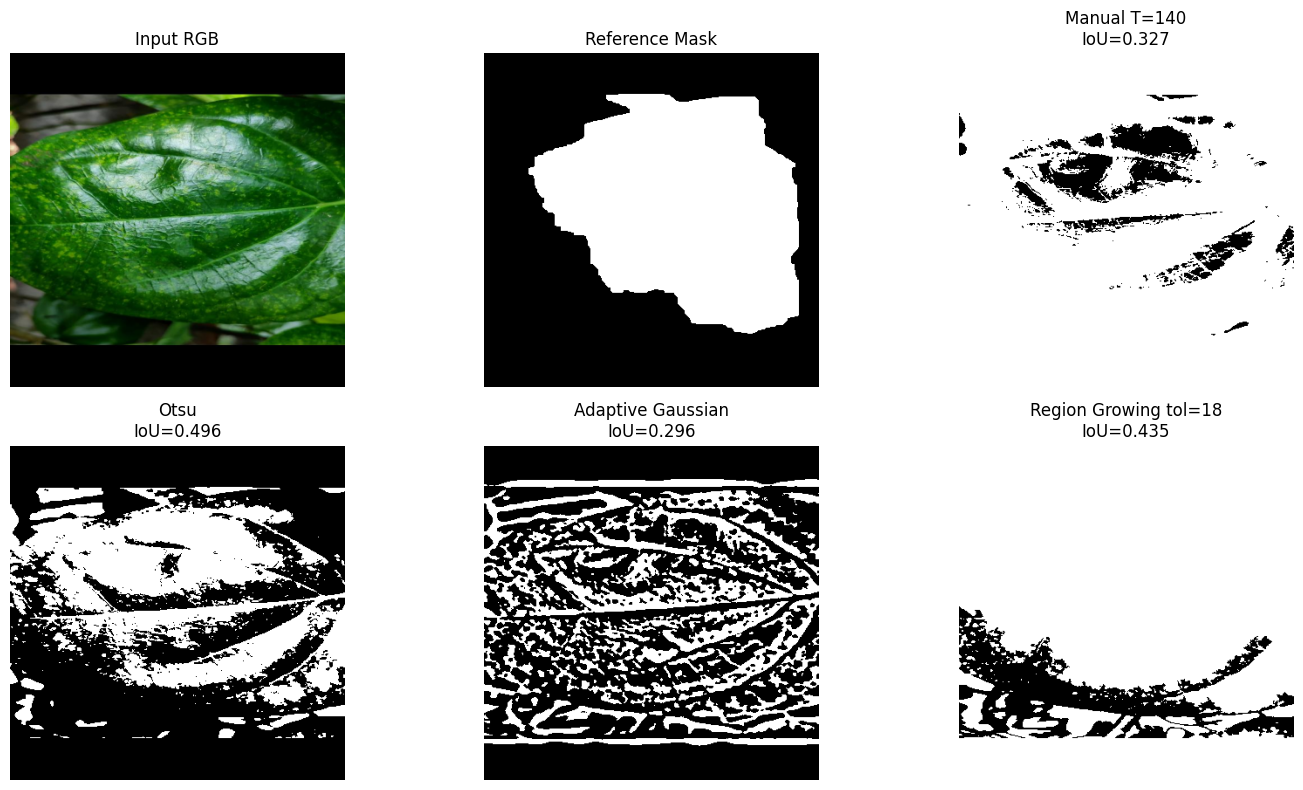

In [14]:
# ============================================================
# 14. Qualitative Comparison of Selected Methods
# ============================================================

comparison_names = [
    "Manual T=140",
    "Otsu",
    "Adaptive Gaussian",
    "Region Growing tol=18"
]

comparison_images = [rgb, reference_mask]
comparison_titles = ["Input RGB", "Reference Mask"]

for name in comparison_names:
    if name in candidate_masks:
        mask = candidate_masks[name]
        best_iou, orientation = best_orientation_iou(mask, reference_mask)
        display_mask = 255 - mask if orientation == "inverted" else mask
        comparison_images.append(display_mask)
        comparison_titles.append(f"{name}\nIoU={best_iou:.3f}")

show_images(
    comparison_images,
    comparison_titles,
    cmap="gray",
    cols=3,
    figsize=(15, 8)
)

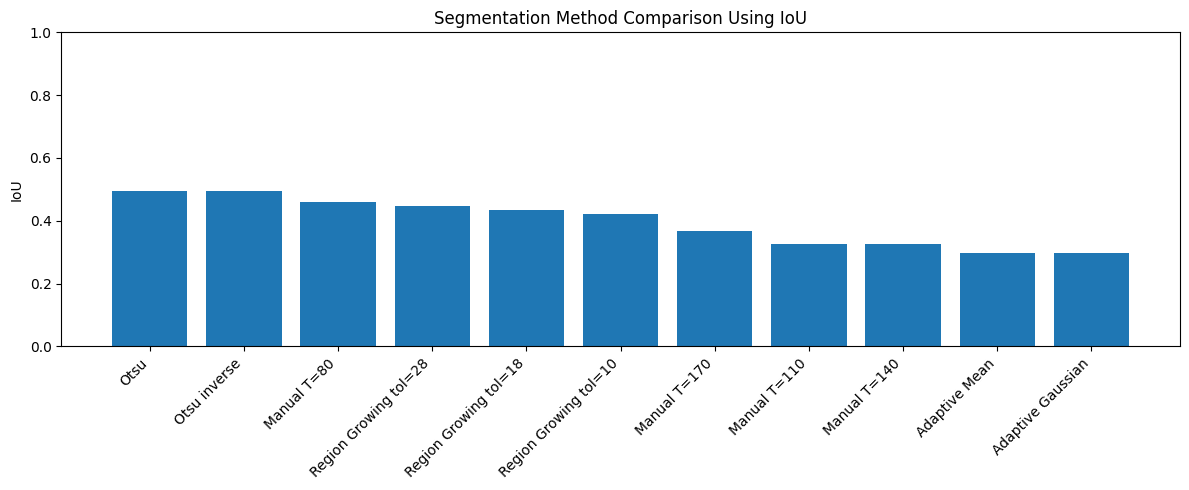

In [15]:
# ============================================================
# 15. IoU Bar Plot
# ============================================================

plt.figure(figsize=(12, 5))
plt.bar(iou_df["Method"], iou_df["Best IoU"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("IoU")
plt.title("Segmentation Method Comparison Using IoU")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 16. Save Main Outputs
# ============================================================

# Save IoU table
iou_df.to_csv(OUTPUT_DIR / "lab11_iou_results.csv", index=False)

# Save important masks
save_gray(OUTPUT_DIR / "manual_threshold_T140.png", manual_masks["Manual T=140"])
save_gray(OUTPUT_DIR / "otsu_mask.png", otsu_mask)
save_gray(OUTPUT_DIR / "adaptive_gaussian_mask.png", adaptive_gaussian)
save_gray(OUTPUT_DIR / "region_growing_tol18.png", region_masks["Region Growing tol=18"])
save_gray(OUTPUT_DIR / "reference_mask_for_iou.png", reference_mask)

print("Saved Lab 11 outputs to:", OUTPUT_DIR)
print("Files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(" -", p.name)

Saved Lab 11 outputs to: /kaggle/working/cse438_lab11_outputs
Files:
 - adaptive_gaussian.png
 - adaptive_gaussian_mask.png
 - adaptive_mean.png
 - lab11_iou_results.csv
 - manual_threshold_T140.png
 - otsu_binary.png
 - otsu_binary_inverse.png
 - otsu_mask.png
 - reference_mask_for_iou.png
 - region_growing_seed.png
 - region_growing_tol10.png
 - region_growing_tol18.png
 - region_growing_tol28.png


In [17]:
# Summary:
# In this lab, we performed segmentation using manual thresholding, Otsu thresholding,
# adaptive local thresholding, and region growing on Betel Leaf images. We also computed
# IoU against a real mask when available, or against a clearly marked pseudo-reference
# mask for classroom metric demonstration. The lab shows that threshold-based segmentation
# is sensitive to illumination and foreground-background contrast, while region growing
# depends strongly on seed placement and intensity tolerance.